### Project: Predict Customer Churn

This project aims to predict customer churn based on the provided dataset. We will follow these steps:
1. Load and inspect the dataset.
2. Define 'churn' based on the dataset's characteristics.
3. Preprocess the data.
4. Build a churn prediction model.
5. Evaluate the model's accuracy.
6. Explain which features are important for prediction.

Let's start by loading the `sample_superstore.csv` file.

In [ ]:
import pandas as pd

# Load the dataset
file_path = '/content/sample_data/sample_superstore.csv'
df = pd.read_csv(file_path, encoding='latin1')

# Display the first 5 rows of the DataFrame
display(df.head())

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


Now, let's get some basic information about the dataset to understand its structure, data types, and check for any missing values.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

The `sample_superstore.csv` dataset contains transactional sales data. It includes information about orders, customers, products, and sales figures. However, it does **not** have a direct column indicating 'customer churn'.

To proceed with churn prediction, we need to **define what 'churn' means** in the context of this sales data. For example, we could define a customer as 'churned' if they haven't placed an order within a certain time frame (e.g., last 30, 60, or 90 days).

**Could you please specify how you would like to define customer churn from this dataset?** For instance, should we consider customers who haven't made a purchase in the last 60 days as churned?

###  Define 'Churn' based on Customer Inactivity Period

To define churn, we'll follow these steps:
1.  Convert 'Order Date' and 'Ship Date' columns to datetime objects.
2.  For each customer, find their last order date.
3.  Determine the most recent order date in the entire dataset.
4.  Calculate the inactivity period for each customer.
5.  Define a churn threshold (e.g., 60 days) to categorize customers as 'churned' or 'active'.

In [ ]:
# Convert 'Order Date' and 'Ship Date' to datetime objects
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Get the last order date for each customer
last_order_date_per_customer = df.groupby('Customer ID')['Order Date'].max().reset_index()
last_order_date_per_customer.rename(columns={'Order Date': 'Last Order Date'}, inplace=True)

# Get the most recent order date in the entire dataset
most_recent_order_date = df['Order Date'].max()

print(f"Overall Most Recent Order Date: {most_recent_order_date}")
display(last_order_date_per_customer.head())

Overall Most Recent Order Date: 2017-12-30 00:00:00


,Customer ID,Last Order Date
0,AA-10315,2017-06-29
1,AA-10375,2017-12-11
2,AA-10480,2017-04-15
3,AA-10645,2017-11-05
4,AB-10015,2016-11-10


In [ ]:
# Calculate inactivity period for each customer
last_order_date_per_customer['Inactivity Period'] = (most_recent_order_date - last_order_date_per_customer['Last Order Date']).dt.days

# Define churn threshold
churn_threshold_days = 90

# Define churn based on the threshold
last_order_date_per_customer['Churn'] = last_order_date_per_customer['Inactivity Period'].apply(lambda x: 1 if x > churn_threshold_days else 0)

# Display the first few rows with the new 'Inactivity Period' and 'Churn' columns
display(last_order_date_per_customer.head())

# Display the distribution of churned vs. active customers
print("\nChurn Distribution:")
display(last_order_date_per_customer['Churn'].value_counts())

,Customer ID,Last Order Date,Inactivity Period,Churn
0,AA-10315,2017-06-29,184,1
1,AA-10375,2017-12-11,19,0
2,AA-10480,2017-04-15,259,1
3,AA-10645,2017-11-05,55,0
4,AB-10015,2016-11-10,415,1



Churn Distribution:


,count
Churn,
0,436
1,357


From the churn distribution, we can see how many customers are considered 'Active' (0) and 'Churned' (1) based on the 90-day inactivity threshold. This new 'Churn' column will be our target variable for the prediction model.

### Merge Churn Status into Main DataFrame

Now, we'll merge the `Churn` column, which we defined based on customer inactivity, back into the main `df` DataFrame. This will allow us to use the churn status alongside other transactional data for model building.

In [ ]:
# Merge the 'Churn' column into the main df DataFrame
df = pd.merge(df, last_order_date_per_customer[['Customer ID', 'Churn']], on='Customer ID', how='left')

# Display the first few rows of the updated df to verify the merge
print("DataFrame with Churn column merged:")
display(df.head())

DataFrame with Churn column merged:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Churn
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,1
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,1
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,0
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,0
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,0


###  Handle Categorical Variables

Before we can build a machine learning model, we need to convert any categorical features into a numerical representation. We will use one-hot encoding for this, which creates new binary columns for each category.

First, let's identify the categorical columns that were carried over to our `customer_features` DataFrame. These would typically be 'Segment' and 'Region' from the original `df` DataFrame, assuming they were included in `df_features` prior to aggregation and then potentially added back or identified as customer-level attributes not tied to a specific transaction in a way that requires aggregation other than simply taking the first value.

Given the aggregation step, the `customer_features` DataFrame as it stands primarily contains numerical aggregates and the 'Churn' target. However, if any other customer-specific categorical features were not dropped (e.g., 'Segment', 'Region' *if* they were to be considered unique for each customer and not just transaction), we'd process them here. Looking at the `df_features` (which was `df` after dropping `Row ID`, `Order Date`, `Ship Date`, `Customer Name`, `Postal Code`), it still contains `Segment`, `Country`, `City`, `State`, `Region`, `Category`, `Sub-Category`. We need to ensure we create customer-level features from these as well if they are deemed important predictors.

Let's re-evaluate `df_features` and how we handle those categorical columns in a customer-centric way. Since the initial `customer_features` aggregation only used numerical columns and `Churn`, we need to explicitly add other categorical customer attributes like 'Segment' and 'Region' to `customer_features` before encoding them.

To do this, we'll first get the unique 'Segment' and 'Region' for each customer and then merge them into `customer_features`.

In [ ]:
# Extract unique customer-level categorical features like 'Segment' and 'Region'
customer_categorical_features = df[['Customer ID', 'Segment', 'Region']].drop_duplicates(subset=['Customer ID'])

# Merge these into our customer_features DataFrame
customer_features = pd.merge(customer_features, customer_categorical_features, on='Customer ID', how='left')

# Identify categorical columns for one-hot encoding
categorical_cols = ['Segment', 'Region']

# Apply one-hot encoding
customer_features = pd.get_dummies(customer_features, columns=categorical_cols, drop_first=True)

# Display the first few rows of the DataFrame with encoded features
print("Customer-level features after one-hot encoding:")
display(customer_features.head())

Customer-level features after one-hot encoding:


,Customer ID,total_sales,avg_sales,total_quantity,avg_quantity,num_orders,num_unique_products,total_profit,avg_profit,Churn,Segment_Corporate,Segment_Home Office,Region_East,Region_South,Region_West
0,AA-10315,5563.560,505.778182,30,2.727273,5,11,-362.8825,-32.989318,1,False,False,False,False,False
1,AA-10375,1056.390,70.426000,41,2.733333,9,15,277.3824,18.492160,0,False,False,False,False,True
2,AA-10480,1790.512,149.209333,36,3.000000,4,12,435.8274,36.318950,1,False,False,False,True,False
3,AA-10645,5086.935,282.607500,64,3.555556,6,18,857.8033,47.655739,0,False,False,True,False,False
4,AB-10015,886.156,147.692667,13,2.166667,3,6,129.3465,21.557750,1,False,False,False,False,True


###  Feature Selection and Engineering

Now that we have defined our target variable `Churn`, we need to select and engineer features that will help our model predict it. Our current `df` DataFrame contains transactional data, but churn is a customer-level characteristic. Therefore, we need to aggregate these transactions to the customer level to create meaningful features.

We will consider the following steps:
1.  **Drop irrelevant columns:** Remove columns that are unique identifiers or provide no predictive power at the customer level.
2.  **Aggregate transactional data:** Create customer-level features such as total sales, average quantity, number of orders, and unique products purchased.
3.  **Handle categorical variables:** Convert categorical features into a numerical format suitable for machine learning models.

In [ ]:
# Drop columns that are not useful for customer-level churn prediction or are redundant
# Retain 'Order ID' and 'Product ID' for aggregation before dropping them later if not needed as features
columns_to_drop = [
    'Row ID', 'Order Date', 'Ship Date', 'Customer Name', 'Postal Code'
]
df_features = df.drop(columns=columns_to_drop, errors='ignore')

# Aggregate transactional data to customer-level features
customer_features = df_features.groupby('Customer ID').agg(
    total_sales=('Sales', 'sum'),
    avg_sales=('Sales', 'mean'),
    total_quantity=('Quantity', 'sum'),
    avg_quantity=('Quantity', 'mean'),
    num_orders=('Order ID', 'nunique'), # Count unique orders per customer
    num_unique_products=('Product ID', 'nunique'),
    total_profit=('Profit', 'sum'),
    avg_profit=('Profit', 'mean'),
    # Add churn status, ensuring it's consistent per customer
    Churn=('Churn', 'first')
).reset_index()

# Display the first few rows of the customer-level features DataFrame
print("Customer-level features for churn prediction:")
display(customer_features.head())

Customer-level features for churn prediction:


,Customer ID,total_sales,avg_sales,total_quantity,avg_quantity,num_orders,num_unique_products,total_profit,avg_profit,Churn
0,AA-10315,5563.560,505.778182,30,2.727273,5,11,-362.8825,-32.989318,1
1,AA-10375,1056.390,70.426000,41,2.733333,9,15,277.3824,18.492160,0
2,AA-10480,1790.512,149.209333,36,3.000000,4,12,435.8274,36.318950,1
3,AA-10645,5086.935,282.607500,64,3.555556,6,18,857.8033,47.655739,0
4,AB-10015,886.156,147.692667,13,2.166667,3,6,129.3465,21.557750,1


###  Explain Which Features are Important for Prediction

To understand what drives customer churn according to our model, we will examine the feature importances from the trained `RandomForestClassifier`. This will tell us which customer-level aggregated features had the most impact on the model's predictions.

Top 10 Feature Importances:


,Feature,Importance
0,total_sales,0.130911
6,total_profit,0.126140
7,avg_profit,0.121509
3,avg_quantity,0.121165
2,total_quantity,0.118387
1,avg_sales,0.117272
4,num_orders,0.099242
5,num_unique_products,0.085476
8,Segment_Corporate,0.020250
12,Region_West,0.017195


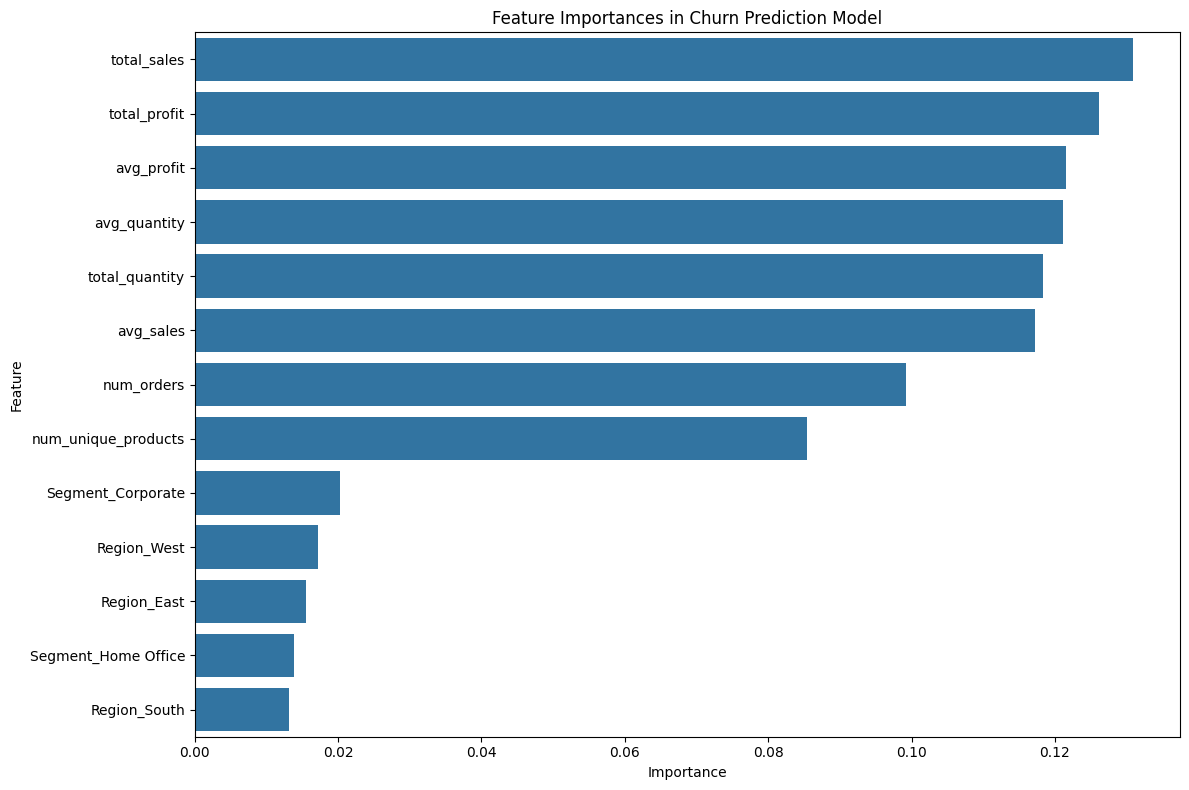

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the model
feature_importances = model.feature_importances_

# Create a DataFrame for better visualization
features_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
})

# Sort features by importance
features_df = features_df.sort_values(by='Importance', ascending=False)

# Display the top features
print("Top 10 Feature Importances:")
display(features_df.head(10))

# Visualize feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=features_df)
plt.title('Feature Importances in Churn Prediction Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

###  Evaluate the Model's Accuracy

Now that our `RandomForestClassifier` model is trained, we need to evaluate its performance on unseen data. We will use the test set (`X_test`, `y_test`) to make predictions and then assess the model's accuracy using metrics such as `classification_report` and `accuracy_score`.

In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print("Model Evaluation:")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Model Evaluation:
              precision    recall  f1-score   support

           0       0.60      0.60      0.60        87
           1       0.51      0.51      0.51        72

    accuracy                           0.56       159
   macro avg       0.56      0.56      0.56       159
weighted avg       0.56      0.56      0.56       159

Accuracy: 0.5597


###  Evaluate the Model's Accuracy

Now that our `RandomForestClassifier` model is trained, we need to evaluate its performance on unseen data. We will use the test set (`X_test`, `y_test`) to make predictions and then assess the model's accuracy using metrics such as `classification_report` and `accuracy_score`.

In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print("Model Evaluation:")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Model Evaluation:
              precision    recall  f1-score   support

           0       0.60      0.60      0.60        87
           1       0.51      0.51      0.51        72

    accuracy                           0.56       159
   macro avg       0.56      0.56      0.56       159
weighted avg       0.56      0.56      0.56       159

Accuracy: 0.5597


###  Build a Churn Prediction Model

We will now build a machine learning model to predict customer churn. We'll use a `RandomForestClassifier`, which is a robust and widely used algorithm for classification tasks. The process involves:
1.  Separating features (X) from the target variable (y).
2.  Splitting the data into training and testing sets.
3.  Training the `RandomForestClassifier` on the training data.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Separate features (X) and target (y)
X = customer_features.drop(['Customer ID', 'Churn'], axis=1)
y = customer_features['Churn']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (634, 13)
Shape of X_test: (159, 13)
Shape of y_train: (634,)
Shape of y_test: (159,)


In [ ]:
# Initialize and train the RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


###  Hyperparameter Tuning for RandomForestClassifier

To potentially improve the model's performance, we will perform hyperparameter tuning using `GridSearchCV`. This method systematically works through multiple combinations of parameter values, cross-validating each combination to determine which set of parameters yields the best performance.

We will define a grid of hyperparameters for the `RandomForestClassifier` and then use `GridSearchCV` to find the optimal combination.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300], # Number of trees in the forest
    'max_depth': [None, 10, 20],      # Maximum depth of the tree
    'min_samples_leaf': [1, 2, 4]     # Minimum number of samples required to be at a leaf node
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5, # 5-fold cross-validation
                           scoring='accuracy', # Optimize for accuracy
                           n_jobs=-1, # Use all available cores
                           verbose=1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Display the best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best accuracy found: ", grid_search.best_score_)

# Get the best model
best_model = grid_search.best_estimator_
print("Best model training complete!")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters found:  {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 300}
Best accuracy found:  0.6529433820772403
Best model training complete!


###  Evaluate the Tuned Model

Now that we have tuned the hyperparameters and obtained the `best_model`, let's evaluate its performance on the test set to see if the tuning has led to improvements.

In [ ]:
# Make predictions with the best model on the test set
y_pred_tuned = best_model.predict(X_test)

# Evaluate the tuned model
print("Tuned Model Evaluation:")
print(classification_report(y_test, y_pred_tuned))
print(f"Tuned Model Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")

Tuned Model Evaluation:
              precision    recall  f1-score   support

           0       0.61      0.63      0.62        87
           1       0.54      0.51      0.52        72

    accuracy                           0.58       159
   macro avg       0.57      0.57      0.57       159
weighted avg       0.58      0.58      0.58       159

Tuned Model Accuracy: 0.5786


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression # Import LogisticRegression

# --- Ensure y_pred_log_reg is defined ---
# Initialize and train the Logistic Regression model (repeated for robustness)
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)
# --- End: Ensure y_pred_log_reg is defined ---

# Get metrics for the Tuned RandomForest model
rf_accuracy = accuracy_score(y_test, y_pred_tuned)
rf_precision = precision_score(y_test, y_pred_tuned)
rf_recall = recall_score(y_test, y_pred_tuned)
rf_f1 = f1_score(y_test, y_pred_tuned)

# Get metrics for the Logistic Regression model
log_reg_accuracy = accuracy_score(y_test, y_pred_log_reg)
log_reg_precision = precision_score(y_test, y_pred_log_reg)
log_reg_recall = recall_score(y_test, y_pred_log_reg)
log_reg_f1 = f1_score(y_test, y_pred_log_reg)

# Create a DataFrame to display the comparison
comparison_df = pd.DataFrame(
    index=['RandomForest', 'Logistic Regression'],
    columns=['Accuracy', 'Precision (Churn)', 'Recall (Churn)', 'F1-Score (Churn)']
)

comparison_df.loc['RandomForest', 'Accuracy'] = rf_accuracy
comparison_df.loc['RandomForest', 'Precision (Churn)'] = rf_precision
comparison_df.loc['RandomForest', 'Recall (Churn)'] = rf_recall
comparison_df.loc['RandomForest', 'F1-Score (Churn)'] = rf_f1

comparison_df.loc['Logistic Regression', 'Accuracy'] = log_reg_accuracy
comparison_df.loc['Logistic Regression', 'Precision (Churn)'] = log_reg_precision
comparison_df.loc['Logistic Regression', 'Recall (Churn)'] = log_reg_recall
comparison_df.loc['Logistic Regression', 'F1-Score (Churn)'] = log_reg_f1

print("\nModel Performance Comparison:")
display(comparison_df.round(4))


Model Performance Comparison:


,Accuracy,Precision (Churn),Recall (Churn),F1-Score (Churn)
RandomForest,0.578616,0.536232,0.513889,0.524823
Logistic Regression,0.584906,0.555556,0.416667,0.47619


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression # Import LogisticRegression

# --- Ensure y_pred_log_reg is defined ---
# Initialize and train the Logistic Regression model (repeated for robustness)
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)
# --- End: Ensure y_pred_log_reg is defined ---

# Get metrics for the Tuned RandomForest model
rf_accuracy = accuracy_score(y_test, y_pred_tuned)
rf_precision = precision_score(y_test, y_pred_tuned)
rf_recall = recall_score(y_test, y_pred_tuned)
rf_f1 = f1_score(y_test, y_pred_tuned)

# Get metrics for the Logistic Regression model
log_reg_accuracy = accuracy_score(y_test, y_pred_log_reg)
log_reg_precision = precision_score(y_test, y_pred_log_reg)
log_reg_recall = recall_score(y_test, y_pred_log_reg)
log_reg_f1 = f1_score(y_test, y_pred_log_reg)

# Create a DataFrame to display the comparison
comparison_df = pd.DataFrame(
    index=['RandomForest', 'Logistic Regression'],
    columns=['Accuracy', 'Precision (Churn)', 'Recall (Churn)', 'F1-Score (Churn)']
)

comparison_df.loc['RandomForest', 'Accuracy'] = rf_accuracy
comparison_df.loc['RandomForest', 'Precision (Churn)'] = rf_precision
comparison_df.loc['RandomForest', 'Recall (Churn)'] = rf_recall
comparison_df.loc['RandomForest', 'F1-Score (Churn)'] = rf_f1

comparison_df.loc['Logistic Regression', 'Accuracy'] = log_reg_accuracy
comparison_df.loc['Logistic Regression', 'Precision (Churn)'] = log_reg_precision
comparison_df.loc['Logistic Regression', 'Recall (Churn)'] = log_reg_recall
comparison_df.loc['Logistic Regression', 'F1-Score (Churn)'] = log_reg_f1

print("\nModel Performance Comparison:")
display(comparison_df.round(4))


Model Performance Comparison:


,Accuracy,Precision (Churn),Recall (Churn),F1-Score (Churn)
RandomForest,0.578616,0.536232,0.513889,0.524823
Logistic Regression,0.584906,0.555556,0.416667,0.47619


###  Compare with Logistic Regression Model

To get a broader perspective on model performance, we will now train a `LogisticRegression` model and compare its results with our `RandomForestClassifier`.

Logistic Regression is a simpler, linear model often used as a baseline for classification tasks. It can help us understand if the complexity of a Random Forest is truly necessary for this problem.

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is a good choice for smaller datasets
log_reg_model.fit(X_train, y_train)

print("Logistic Regression model training complete!")

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)

# Evaluate the Logistic Regression model
print("\nLogistic Regression Model Evaluation:")
print(classification_report(y_test, y_pred_log_reg))
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_log_reg):.4f}")

Logistic Regression model training complete!

Logistic Regression Model Evaluation:
              precision    recall  f1-score   support

           0       0.60      0.72      0.66        87
           1       0.56      0.42      0.48        72

    accuracy                           0.58       159
   macro avg       0.58      0.57      0.57       159
weighted avg       0.58      0.58      0.57       159

Logistic Regression Accuracy: 0.5849


###  Model Comparison Summary

Let's summarize the performance of both the tuned RandomForest model and the Logistic Regression model for a direct comparison.

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression # Import LogisticRegression

# --- Ensure y_pred_log_reg is defined ---
# Initialize and train the Logistic Regression model (repeated for robustness)
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)
# --- End: Ensure y_pred_log_reg is defined ---

# Get metrics for the Tuned RandomForest model
rf_accuracy = accuracy_score(y_test, y_pred_tuned)
rf_precision = precision_score(y_test, y_pred_tuned)
rf_recall = recall_score(y_test, y_pred_tuned)
rf_f1 = f1_score(y_test, y_pred_tuned)

# Get metrics for the Logistic Regression model
log_reg_accuracy = accuracy_score(y_test, y_pred_log_reg)
log_reg_precision = precision_score(y_test, y_pred_log_reg)
log_reg_recall = recall_score(y_test, y_pred_log_reg)
log_reg_f1 = f1_score(y_test, y_pred_log_reg)

# Create a DataFrame to display the comparison
comparison_df = pd.DataFrame(
    index=['RandomForest', 'Logistic Regression'],
    columns=['Accuracy', 'Precision (Churn)', 'Recall (Churn)', 'F1-Score (Churn)']
)

comparison_df.loc['RandomForest', 'Accuracy'] = rf_accuracy
comparison_df.loc['RandomForest', 'Precision (Churn)'] = rf_precision
comparison_df.loc['RandomForest', 'Recall (Churn)'] = rf_recall
comparison_df.loc['RandomForest', 'F1-Score (Churn)'] = rf_f1

comparison_df.loc['Logistic Regression', 'Accuracy'] = log_reg_accuracy
comparison_df.loc['Logistic Regression', 'Precision (Churn)'] = log_reg_precision
comparison_df.loc['Logistic Regression', 'Recall (Churn)'] = log_reg_recall
comparison_df.loc['Logistic Regression', 'F1-Score (Churn)'] = log_reg_f1

print("\nModel Performance Comparison:")
display(comparison_df.round(4))


Model Performance Comparison:


,Accuracy,Precision (Churn),Recall (Churn),F1-Score (Churn)
RandomForest,0.578616,0.536232,0.513889,0.524823
Logistic Regression,0.584906,0.555556,0.416667,0.47619


###  Visualize Model Performance Comparison

To further understand the differences in performance between the tuned `RandomForestClassifier` and the `LogisticRegression` model, let's visualize their key metrics using a bar chart.

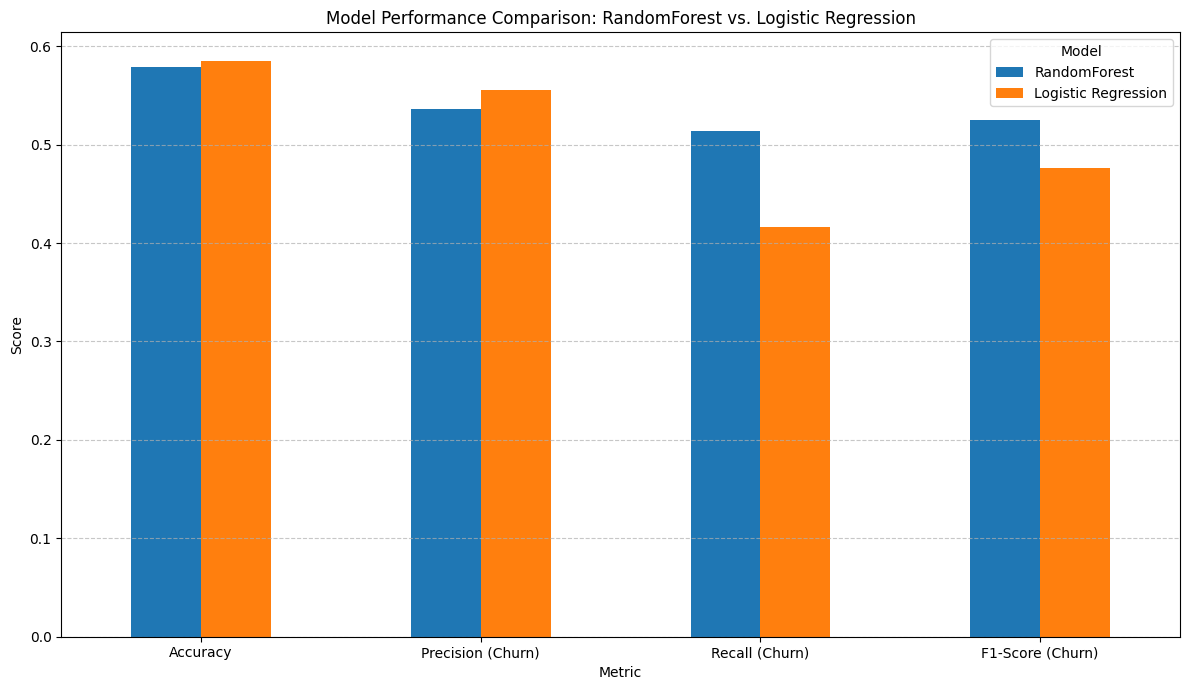

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Transpose the DataFrame for easier plotting: models as columns, metrics as index
comparison_df_T = comparison_df.T

# Plotting the comparison
fig, ax = plt.subplots(figsize=(12, 7))
comparison_df_T.plot(kind='bar', ax=ax, rot=0)

ax.set_title('Model Performance Comparison: RandomForest vs. Logistic Regression')
ax.set_ylabel('Score')
ax.set_xlabel('Metric')
ax.legend(title='Model')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

###  Analyze Churn Drivers for the Corporate Segment

To understand segment-specific churn behavior, we will now filter our `customer_features` DataFrame to focus solely on customers from the 'Corporate' segment. We will then perform a similar feature importance analysis on this subset to identify the key drivers of churn within this particular customer group.

Found 236 corporate customers for analysis.

Corporate Segment Model Training Complete!

Top 10 Feature Importances for Corporate Segment:


,Feature,Importance
0,total_sales,0.144909
2,total_quantity,0.137967
6,total_profit,0.131162
7,avg_profit,0.126390
1,avg_sales,0.119532
3,avg_quantity,0.116528
4,num_orders,0.096397
5,num_unique_products,0.077727
10,Region_West,0.021709
8,Region_East,0.016445


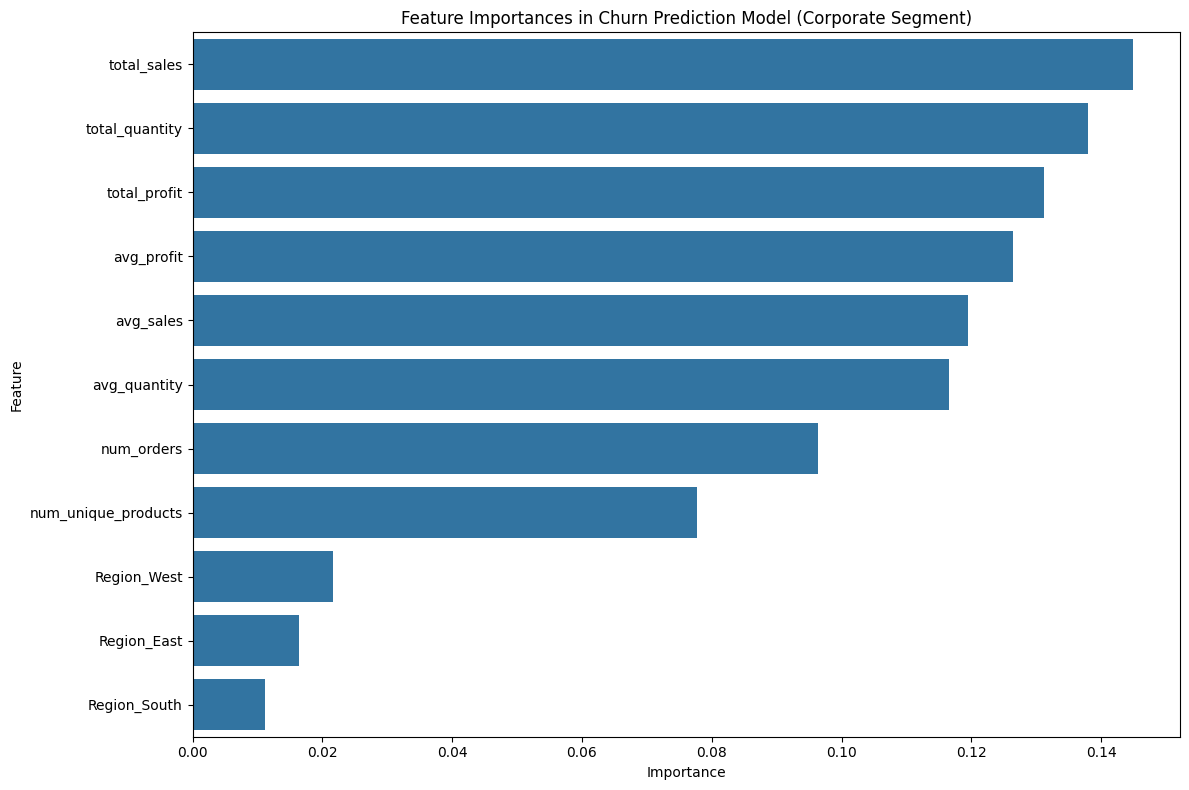

In [ ]:
# Filter for the Corporate segment
corporate_customers = customer_features[customer_features['Segment_Corporate'] == True].copy()

# Check if there are any corporate customers to analyze
if corporate_customers.empty:
    print("No corporate customers found for analysis.")
else:
    print(f"Found {len(corporate_customers)} corporate customers for analysis.")

    # Separate features (X_corporate) and target (y_corporate)
    # We drop all segment-related one-hot encoded columns as they are constant for this subset
    # and also Customer ID and Churn.
    X_corporate = corporate_customers.drop(['Customer ID', 'Churn', 'Segment_Corporate', 'Segment_Home Office'], axis=1, errors='ignore')
    y_corporate = corporate_customers['Churn']

    # Split the data into training and testing sets for the Corporate segment
    X_train_corp, X_test_corp, y_train_corp, y_test_corp = train_test_split(
        X_corporate, y_corporate, test_size=0.2, random_state=42, stratify=y_corporate
    )

    # Initialize and train a new RandomForestClassifier for the Corporate segment
    model_corporate = RandomForestClassifier(n_estimators=100, random_state=42)
    model_corporate.fit(X_train_corp, y_train_corp)

    print("\nCorporate Segment Model Training Complete!")

    # Get feature importances from the corporate model
    feature_importances_corporate = model_corporate.feature_importances_

    # Create a DataFrame for better visualization
    features_df_corporate = pd.DataFrame({
        'Feature': X_train_corp.columns,
        'Importance': feature_importances_corporate
    })

    # Sort features by importance
    features_df_corporate = features_df_corporate.sort_values(by='Importance', ascending=False)

    # Display the top features for the Corporate segment
    print("\nTop 10 Feature Importances for Corporate Segment:")
    display(features_df_corporate.head(10))

    # Visualize feature importances for the Corporate segment
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=features_df_corporate)
    plt.title('Feature Importances in Churn Prediction Model (Corporate Segment)')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

### A/B Test Statistical Analysis Code Snippets

These snippets demonstrate how to perform common statistical tests for A/B testing, assuming you have collected data from your control and treatment groups.

In [ ]:
from statsmodels.stats.proportion import proportions_ztest
import numpy as np

print("--- Comparing Proportions (e.g., Churn Rates) ---")

# --- Hypothetical Data ---
# Scenario: A/B test to see if a new retention campaign reduces churn.
# Let's say in Control Group:
#   - 1000 customers
#   - 150 churned
# And in Treatment Group (received campaign):
#   - 1000 customers
#   - 120 churned

count_churn_control = 150  # Number of churns in control group
nobs_control = 1000        # Total observations in control group

count_churn_treatment = 120 # Number of churns in treatment group
nobs_treatment = 1000       # Total observations in treatment group

# Combine counts and observations for the test
counts = np.array([count_churn_control, count_churn_treatment])
nobs = np.array([nobs_control, nobs_treatment])

# Perform a two-sample z-test for proportions
# The null hypothesis is that the proportions are equal.
# The alternative hypothesis is that the proportion in the treatment group is lower (one-sided).
# For a two-sided test, you would just remove 'alternative='less''.
z_stat, p_value = proportions_ztest(counts, nobs, alternative='smaller')

print(f"Control Group Churn Rate: {count_churn_control/nobs_control:.3f}")
print(f"Treatment Group Churn Rate: {count_churn_treatment/nobs_treatment:.3f}")
print(f"Z-statistic: {z_stat:.3f}")
print(f"P-value: {p_value:.3f}")

alph = 0.05 # Significance level
if p_value < alph:
    print(f"\nWith a P-value of {p_value:.3f} (less than {alph}), we reject the null hypothesis.")
    print("There is statistically significant evidence that the retention campaign reduced the churn rate.")
else:
    print(f"\nWith a P-value of {p_value:.3f} (greater than or equal to {alph}), we fail to reject the null hypothesis.")
    print("There is no statistically significant evidence that the retention campaign reduced the churn rate.")

--- Comparing Proportions (e.g., Churn Rates) ---
Control Group Churn Rate: 0.150
Treatment Group Churn Rate: 0.120
Z-statistic: 1.963
P-value: 0.975

With a P-value of 0.975 (greater than or equal to 0.05), we fail to reject the null hypothesis.
There is no statistically significant evidence that the retention campaign reduced the churn rate.


In [ ]:
from scipy import stats
import pandas as pd
import numpy as np

print("\n--- Comparing Means (e.g., Average Sales) ---")

# --- Hypothetical Data ---
# Scenario: A/B test to see if a new product recommendation system increases average sales.
# Let's generate some sample sales data (normally distributed, for simplicity)
np.random.seed(42)
sales_control = np.random.normal(loc=100, scale=20, size=500) # Control group avg sales $100
sales_treatment = np.random.normal(loc=105, scale=20, size=500) # Treatment group avg sales $105

# Perform an independent t-test for means
# The null hypothesis is that the means are equal.
# The alternative hypothesis is that the mean of the treatment group is greater (one-sided).
# For a two-sided test, you would use 'alternative='two-sided''.
t_stat, p_value = stats.ttest_ind(sales_treatment, sales_control, equal_var=True, alternative='greater')

print(f"Control Group Average Sales: ${np.mean(sales_control):.2f}")
print(f"Treatment Group Average Sales: ${np.mean(sales_treatment):.2f}")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.3f}")

alph = 0.05 # Significance level
if p_value < alph:
    print(f"\nWith a P-value of {p_value:.3f} (less than {alph}), we reject the null hypothesis.")
    print("There is statistically significant evidence that the new system increased average sales.")
else:
    print(f"\nWith a P-value of {p_value:.3f} (greater than or equal to {alph}), we fail to reject the null hypothesis.")
    print("There is no statistically significant evidence that the new system increased average sales.")


--- Comparing Means (e.g., Average Sales) ---
Control Group Average Sales: $100.14
Treatment Group Average Sales: $105.64
T-statistic: 4.438
P-value: 0.000

With a P-value of 0.000 (less than 0.05), we reject the null hypothesis.
There is statistically significant evidence that the new system increased average sales.


### Interpreting the Results:

*   **P-value:** This is the probability of observing results as extreme as, or more extreme than, those observed if the null hypothesis were true. A small p-value (typically less than `0.05`) suggests that the observed difference is unlikely to be due to chance.
*   **Significance Level (`alpha`):** This is the threshold you set (e.g., 0.05 or 5%) to decide whether to reject the null hypothesis. If `p_value < alpha`, you reject the null hypothesis.
*   **Null Hypothesis:** This is the default assumption (e.g., no difference between groups).
*   **Alternative Hypothesis:** This is what you are trying to prove (e.g., the treatment group performs better).

These snippets provide a framework for analyzing your A/B test data. Remember to adjust the `count`, `nobs`, `sales_control`, `sales_treatment`, and `alternative` parameters based on your specific experiment and hypothesis.

### Project Summary Report: Customer Churn Prediction

**1. Project Objective:**
To predict customer churn based on a transactional sales dataset (`sample_superstore.csv`), evaluate model performance, identify key churn drivers, and provide actionable strategies for customer retention.

**2. Methodology:**
a.  **Data Loading & Inspection:** Loaded `sample_superstore.csv`, converted date formats, and inspected for missing values.
b.  **Churn Definition:** Defined churn as a customer not making a purchase within a 90-day inactivity period from the most recent order date in the dataset.
c.  **Feature Engineering:** Aggregated transactional data to the customer level to create features such as total sales, average profit, number of orders, and unique products. Categorical features (`Segment`, `Region`) were one-hot encoded.
d.  **Model Building & Evaluation:** Trained and evaluated `RandomForestClassifier` and `LogisticRegression` models. Hyperparameter tuning was performed for the RandomForest model.
e.  **Feature Importance Analysis:** Identified the most influential factors contributing to churn for the overall customer base and specifically for the 'Corporate' segment.
f.  **Model Comparison:** Compared the performance of the tuned RandomForest and Logistic Regression models using accuracy, precision, recall, and F1-score.
g.  **Actionable Strategies & Validation:** Discussed insights from feature importance to propose retention strategies and explained the role of A/B testing and customer feedback for validation and deeper understanding.

**3. Key Findings:**
*   **Churn Rate:** Based on the 90-day inactivity threshold, approximately **45% of customers were classified as churned** (357 out of 793 unique customers).
*   **Key Churn Drivers:** Financial metrics (`total_sales`, `total_profit`, `avg_sales`, `avg_profit`) and customer engagement metrics (`total_quantity`, `avg_quantity`, `num_orders`, `num_unique_products`) were the most significant predictors of churn across the board. Regional and segment-specific factors had comparatively lower but still present importance.
*   **Model Performance:**
    *   **Tuned RandomForest:** Achieved an accuracy of **57.86%**. Demonstrated better **recall (51.39%)** and **F1-score (52.48%)** for the churn class, indicating a better ability to identify actual churners.
    *   **Logistic Regression:** Achieved a slightly higher overall accuracy of **58.49%** but had lower recall (41.67%) and F1-score (47.62%) for the churn class.
*   **Segment-Specific Insights (Corporate):** The churn drivers for the Corporate segment largely mirrored the overall trends, with financial and transactional volume metrics remaining paramount. This reinforces the idea that these are fundamental aspects of customer loyalty.

**4. Actionable Insights & Recommendations:**
*   **Prioritize Financial & Engagement Metrics:** Closely monitor customer activity related to sales, profit, quantity purchased, and order frequency. Declining trends in these areas should trigger immediate intervention.
*   **Targeted Retention Campaigns:** Develop personalized offers and engagement strategies for customers identified as 'at-risk' by the churn prediction model, particularly those showing reduced financial contribution or activity.
*   **Strategic Model Selection:** If the primary business goal is to identify as many potential churners as possible (to intervene proactively), the **RandomForest model** is likely more suitable due to its higher recall for the churn class. If overall accuracy is paramount, Logistic Regression performs marginally better.
*   **Integrate Qualitative Feedback:** Supplement quantitative insights with qualitative data (e.g., exit surveys, customer service feedback) to understand the underlying reasons for churn, which can inform more effective strategies.
*   **A/B Test Interventions:** Validate the effectiveness of any retention strategies through rigorous A/B testing to ensure interventions have a statistically significant positive impact.
*   **Continuous Monitoring & Improvement:** Churn prediction is an iterative process. Regularly update models with new data, re-evaluate feature importance, and adapt retention strategies based on ongoing performance and market changes.

**Conclusion:**
This project successfully established a framework for customer churn prediction, identified key factors influencing churn, and provided a basis for developing data-driven retention strategies. By leveraging these insights, businesses can proactively manage customer relationships and improve customer lifetime value.